In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
from keras.applications.vgg16 import VGG16

In [3]:
model=VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


In [4]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import cv2

In [10]:
import cv2
import numpy as np
import urllib.request

url = "https://images-prd.deshabhimani.com/cat6-1744094950340-e44df3c1-dcf7-4164-8199-1182c8d838df-900x506.webp"

# Read image from URL
resp = urllib.request.urlopen(url)
image_data = np.asarray(bytearray(resp.read()), dtype=np.uint8)

# Decode the image
img = cv2.imdecode(image_data, cv2.IMREAD_COLOR)

# Check if loaded successfully
if img is None:
    print("Error: Image not loaded.")
else:
    img = cv2.resize(img, (224, 224))
    print("Image loaded and resized successfully:", img.shape)


Image loaded and resized successfully: (224, 224, 3)


In [11]:
img = cv2.resize(img,( 224,224))

array([[[183, 205, 222],
        [185, 204, 222],
        [187, 204, 222],
        ...,
        [186, 205, 224],
        [186, 205, 224],
        [185, 203, 223]],

       [[183, 205, 222],
        [185, 204, 222],
        [187, 204, 222],
        ...,
        [186, 205, 224],
        [186, 205, 224],
        [185, 203, 223]],

       [[185, 204, 222],
        [186, 204, 222],
        [187, 204, 222],
        ...,
        [186, 205, 224],
        [186, 205, 224],
        [185, 203, 223]],

       ...,

       [[130, 184, 228],
        [131, 185, 228],
        [134, 185, 229],
        ...,
        [132, 187, 233],
        [131, 186, 232],
        [130, 185, 230]],

       [[130, 184, 228],
        [132, 184, 228],
        [133, 185, 229],
        ...,
        [132, 187, 233],
        [131, 186, 232],
        [130, 185, 230]],

       [[132, 184, 228],
        [133, 184, 228],
        [132, 186, 229],
        ...,
        [132, 188, 231],
        [132, 187, 233],
        [131, 186, 232]]], dtype=uint8)
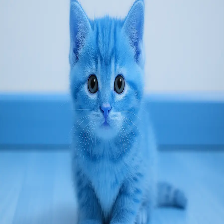

In [12]:
img

In [13]:
img=np.array(img)

In [14]:
img = img.reshape(1,224,224,3)

In [15]:
img.shape

(1, 224, 224, 3)

In [16]:
from keras.applications.vgg16 import preprocess_input

In [17]:
image = preprocess_input(img)

In [18]:
result = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [19]:
result

array([[7.18380079e-07, 1.68774190e-04, 2.50425182e-05, 6.60354635e-05,
        4.17547053e-05, 1.28900328e-05, 2.95356443e-07, 1.44483411e-05,
        1.02761051e-05, 6.37229641e-06, 1.45788772e-05, 1.29018154e-05,
        1.90637911e-05, 4.08410560e-05, 3.60941485e-05, 1.09271787e-05,
        6.39352857e-06, 2.75655591e-04, 2.97955421e-06, 6.80425319e-06,
        1.43306613e-06, 3.74840092e-05, 1.81236874e-06, 3.03039769e-06,
        2.20684797e-05, 1.54536121e-06, 2.66938969e-05, 6.01331994e-05,
        1.70356668e-06, 5.95203746e-05, 1.40674399e-06, 2.55236773e-05,
        3.89866227e-06, 7.65150787e-07, 1.11580368e-06, 1.98279693e-07,
        7.41758504e-06, 5.04564582e-07, 9.61537298e-05, 2.37881750e-06,
        6.79215242e-04, 1.28880047e-05, 1.60717813e-04, 2.86276390e-05,
        1.36957053e-04, 1.93682035e-06, 1.37694390e-03, 1.02216336e-05,
        1.12152634e-06, 2.54315637e-07, 6.23194353e-07, 6.68374832e-06,
        2.19111651e-04, 8.08651748e-06, 2.23841344e-05, 2.357676

In [20]:
from keras.applications.vgg16 import decode_predictions

In [21]:
pred_class = decode_predictions(result,top=5)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
for i in pred_class[0]:
    print(i)

('n02124075', 'Egyptian_cat', np.float32(0.24894743))
('n03887697', 'paper_towel', np.float32(0.08746839))
('n04209239', 'shower_curtain', np.float32(0.07356773))
('n02808304', 'bath_towel', np.float32(0.060252003))
('n04423845', 'thimble', np.float32(0.0515519))


In [31]:
from keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.preprocessing.image import img_to_array

In [32]:
img = load_img("/content/dog.png",target_size=(224,224))

In [33]:
img=img_to_array(img)

In [34]:
img.shape

(224, 224, 3)

In [35]:
img = np.expand_dims(img,axis=0)

In [36]:
img.shape

(1, 224, 224, 3)

In [37]:
from keras.applications.vgg16 import preprocess_input

In [39]:
preprocess_input(img)

array([[[[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ]],

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ]],

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ]],

        ...,

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,


In [43]:
pred =model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step


In [41]:
from keras.applications.vgg16 import decode_predictions

In [46]:
result_val = decode_predictions(pred, top=1)

In [47]:
result_val

[[('n02124075', 'Egyptian_cat', np.float32(0.24894743))]]

In [49]:
decode_predictions(np.expand_dims(np.arange(1000),0), top = 1000)

[[('n15075141', 'toilet_tissue', np.int64(999)),
  ('n13133613', 'ear', np.int64(998)),
  ('n13054560', 'bolete', np.int64(997)),
  ('n13052670', 'hen-of-the-woods', np.int64(996)),
  ('n13044778', 'earthstar', np.int64(995)),
  ('n13040303', 'stinkhorn', np.int64(994)),
  ('n13037406', 'gyromitra', np.int64(993)),
  ('n12998815', 'agaric', np.int64(992)),
  ('n12985857', 'coral_fungus', np.int64(991)),
  ('n12768682', 'buckeye', np.int64(990)),
  ('n12620546', 'hip', np.int64(989)),
  ('n12267677', 'acorn', np.int64(988)),
  ('n12144580', 'corn', np.int64(987)),
  ('n12057211', "yellow_lady's_slipper", np.int64(986)),
  ('n11939491', 'daisy', np.int64(985)),
  ('n11879895', 'rapeseed', np.int64(984)),
  ('n10565667', 'scuba_diver', np.int64(983)),
  ('n10148035', 'groom', np.int64(982)),
  ('n09835506', 'ballplayer', np.int64(981)),
  ('n09472597', 'volcano', np.int64(980)),
  ('n09468604', 'valley', np.int64(979)),
  ('n09428293', 'seashore', np.int64(978)),
  ('n09421951', 'sandbar'